# Capítulo 2 — Formación de imagen: óptica, sensores y ruido

## Objetivo del notebook

En el capítulo anterior estudiamos la imagen como una matriz y como una función bidimensional discretizada.  
Ahora damos un paso mucho más importante: entender una imagen real como resultado de un **proceso físico de formación de imagen**.

---

La formación de imagen puede modelarse con:

$$
g(x,y) = f(x,y) \otimes h(x,y) + n(x,y)
$$


donde:

- $f(x,y)$ es el objeto original
- $h(x,y)$ es la PSF del sistema
- $\otimes$ es la convolución
- $n(x,y)$ es el ruido
- $g(x,y)$ es la imagen observada

Este modelo será el puente entre:

- óptica
- teoría de sistemas
- procesamiento de imágenes
- deconvolución
- machine learning


## 1. ¿Qué significa “formación de imagen”?

Cuando tomamos una fotografía, observamos por un microscopio o registramos una escena con una cámara, ocurre una cadena de procesos físicos.

De forma simplificada:

1. El objeto refleja o emite luz  
2. Esa luz viaja a través del sistema óptico  
3. El sistema modifica la distribución espacial de la luz  
4. El sensor registra una versión discreta y ruidosa de esa información  

Por tanto, la imagen final depende no solo del objeto, sino también de:

- La calidad del sistema óptico
- La apertura
- La difracción
- El enfoque
- Las aberraciones
- El sensor
- El ruido electrónico

La idea importante es que la imagen observada siempre está mediada por un sistema.


## 2. Un punto no se registra como un punto

Esta es una de las ideas más profundas de la óptica de formación de imagen. Supongamos que el objeto contiene un punto luminoso idealmente infinitamente pequeño.  Es natural pensar que en la imagen aparecería otro punto infinitamente pequeño. Pero eso no ocurre. En un sistema real, un punto del objeto se transforma en una pequeña distribución extendida de luz en el plano imagen.

Esa distribución depende del sistema y recibe el nombre de **PSF — Point Spread Function**. La PSF es entonces la respuesta del sistema a un punto. Esta definición es crucial porque, si sabemos cómo responde el sistema a un punto, podemos inferir cómo responderá a objetos más complejos.


## 3. La PSF y la idea de sistema lineal

Si el sistema óptico puede aproximarse como:

- lineal
- invariante ante traslación

entonces la salida completa del sistema queda determinada por su respuesta impulsional.

En señales de una variable, esa respuesta es $h(t)$.  
En imágenes, la versión bidimensional es $h(x,y)$.

Desde esta perspectiva:

> la PSF es la respuesta al impulso espacial del sistema de imagen.


## 4. Modelo matemático de formación de imagen

El modelo fundamental es:

$$
g(x,y) = f(x,y) \otimes h(x,y) + n(x,y)
$$

Interpretación detallada:

- $f(x,y)$: objeto o escena ideal
- $h(x,y)$: PSF del sistema
- $f \otimes h$: salida desenfocada por el sistema
- $n(x,y)$: ruido añadido
- $g(x,y)$: imagen finalmente registrada

Este modelo contiene dos tipos de degradación diferentes:

### Degradación estructurada
Proviene del sistema óptico y se modela mediante la convolución con la PSF.

### Degradación aleatoria
Proviene del ruido del sensor o del proceso de adquisición.

Más adelante veremos que ambas degradaciones se comportan de forma distinta y exigen estrategias distintas de restauración.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["image.cmap"] = "gray"


## 5. Construcción de un objeto simple

Empezaremos con un objeto artificial muy sencillo para que el proceso de degradación se vea con claridad. Usaremos un cuadrado brillante sobre fondo oscuro.


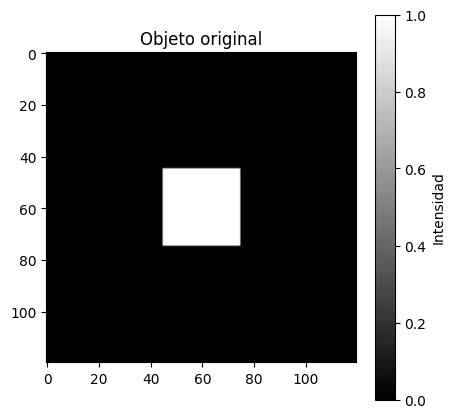

Shape: (120, 120)
Valor mínimo: 0.0
Valor máximo: 1.0


In [2]:
img = np.zeros((120, 120), dtype=float)
img[45:75, 45:75] = 1.0

plt.figure(figsize=(5,5))
plt.imshow(img, vmin=0, vmax=1)
plt.title("Objeto original")
plt.colorbar(label="Intensidad")
plt.show()

print("Shape:", img.shape)
print("Valor mínimo:", img.min())
print("Valor máximo:", img.max())


### Interpretación

Este objeto tiene bordes abruptos y contraste máximo:

- fondo = 0
- cuadrado = 1

Todavía no hay sistema óptico ni ruido.  
Esta imagen representa la “verdad” ideal con la que compararemos todos los resultados posteriores.


## 6. Perfil de intensidad del objeto

Antes de degradar la imagen, observemos una fila horizontal central como señal 1D. Esto permite visualizar con mucha claridad el efecto del sistema óptico.


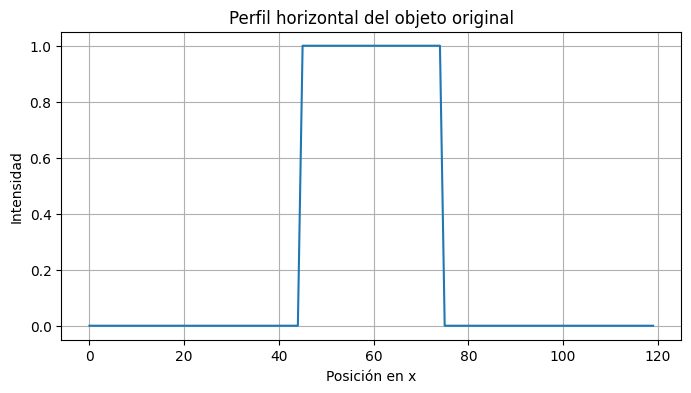

In [3]:
fila_original = img[img.shape[0] // 2, :]

plt.figure(figsize=(8,4))
plt.plot(fila_original)
plt.title("Perfil horizontal del objeto original")
plt.xlabel("Posición en x")
plt.ylabel("Intensidad")
plt.grid(True)
plt.show()


En esta gráfica se ven transiciones abruptas:

- la intensidad salta de 0 a 1
- luego permanece constante
- luego vuelve bruscamente a 0

Un sistema óptico real tiende a suavizar este tipo de transiciones.  
Esa suavización es una de las manifestaciones más visibles del blur.


## 7. Primera PSF: promedio uniforme

Construiremos primero una PSF muy simple: una ventana uniforme.

No es la PSF física exacta de una lente, pero sí es muy útil para entender la lógica de la convolución:

- cada píxel se mezcla con sus vecinos
- los bordes se difuminan
- la imagen pierde nitidez

A este tipo de PSF a veces se le llama **box blur**.


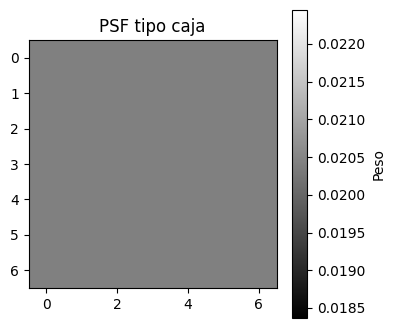

Shape de la PSF: (7, 7)
Suma de la PSF: 0.9999999999999999


In [4]:
psf_box = np.ones((7, 7), dtype=float)
psf_box = psf_box / psf_box.sum()

plt.figure(figsize=(4,4))
plt.imshow(psf_box)
plt.title("PSF tipo caja")
plt.colorbar(label="Peso")
plt.show()

print("Shape de la PSF:", psf_box.shape)
print("Suma de la PSF:", psf_box.sum())


### ¿Por qué la suma debe ser 1?

Porque queremos que la PSF esté normalizada.

Si la suma total de pesos fuera mayor que 1, el sistema aumentaría artificialmente la energía.  
Si fuera menor que 1, la imagen se atenuaría.

Normalizar la PSF significa que redistribuimos la energía, pero no la inventamos ni la destruimos arbitrariamente.


## 8. Formación de imagen mediante convolución

Ahora hacemos exactamente lo que dice el modelo:

$$
g(x,y) = f(x,y) \otimes h(x,y)
$$

Por el momento no añadiremos ruido, para aislar únicamente el efecto del sistema.


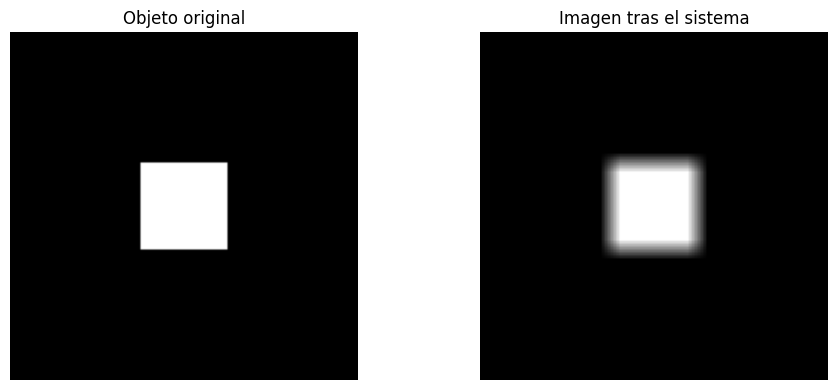

In [5]:
img_blur_box = convolve2d(img, psf_box, mode="same", boundary="fill", fillvalue=0)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, vmin=0, vmax=1)
plt.title("Objeto original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_blur_box, vmin=0, vmax=1)
plt.title("Imagen tras el sistema")
plt.axis("off")

plt.tight_layout()
plt.show()


### Qué está ocurriendo físicamente

La convolución hace que cada punto del objeto contribuya no solo a su posición original, sino también a posiciones vecinas.

Eso significa que:

- la energía se dispersa
- los bordes se suavizan
- la imagen pierde definición espacial

Este es uno de los mensajes más importantes del capítulo:

> la imagen observada no es el objeto, sino el objeto “propagado” por el sistema.


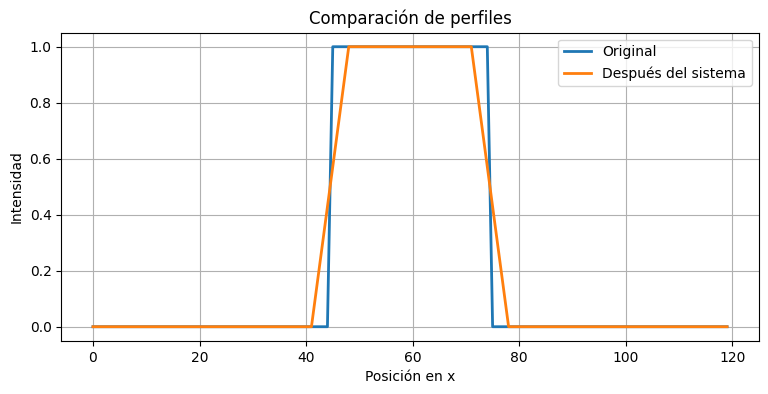

In [6]:
fila_blur_box = img_blur_box[img_blur_box.shape[0] // 2, :]

plt.figure(figsize=(9,4))
plt.plot(fila_original, label="Original", linewidth=2)
plt.plot(fila_blur_box, label="Después del sistema", linewidth=2)
plt.title("Comparación de perfiles")
plt.xlabel("Posición en x")
plt.ylabel("Intensidad")
plt.grid(True)
plt.legend()
plt.show()


Aquí se ve con mucha claridad la pérdida de nitidez.

La señal original tenía transiciones abruptas.  
La señal después del sistema tiene transiciones suaves.

Ese “redondeo” de bordes es exactamente la firma del blur introducido por la PSF.


## 9. Una PSF más realista: la gaussiana

Aunque la PSF tipo caja es útil para comprender la idea de convolución, resulta poco representativa de los sistemas reales. En la práctica, muchos procesos físicos de formación de imagen generan desenfoques **suaves y graduales**, no uniformes.

Por esta razón, una aproximación mucho más realista es la **PSF gaussiana**, definida como:

$$
h(x,y) = \frac{1}{2\pi \sigma^2} \, \exp\!\left(-\frac{x^2 + y^2}{2\sigma^2}\right)
$$

donde:

- $\sigma$ controla la dispersión (nivel de desenfoque)
- $(x,y)$ representa la distancia respecto al centro de la PSF



### Interpretación física

La función gaussiana presenta dos características fundamentales:

- el valor máximo se concentra en el centro, donde se encuentra la mayor contribución del punto original  
- los valores decrecen de manera continua y suave a medida que aumenta la distancia al centro  

En términos físicos, esto implica que:

> La energía de un punto se distribuye principalmente en su vecindad inmediata y se disipa progresivamente hacia el exterior.

Este comportamiento describe de forma más fiel muchos fenómenos reales, como:

- desenfoque óptico  
- difusión de luz en sensores  
- limitaciones de resolución en sistemas físicos  



### Relación con la formación de imagen

Al utilizar una PSF gaussiana en el modelo:

$$
g(x,y) = f(x,y) \otimes h(x,y)
$$

se obtiene un desenfoque más natural, donde la contribución de cada punto del objeto está ponderada según su proximidad, en lugar de distribuirse de manera uniforme como en el caso de la PSF tipo caja.

Por esta razón, la PSF gaussiana es uno de los modelos más utilizados en **óptica**, **procesamiento de imágenes** y **análisis en el dominio de Fourier**.

In [7]:
def gaussian_psf(size=21, sigma=3.0):
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    psf = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    psf /= psf.sum()
    return psf

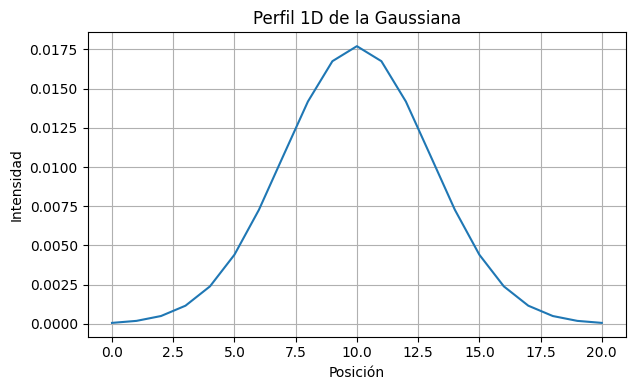

In [18]:
psf_gauss = gaussian_psf(size=21, sigma=3)

# =========================
# Visualización
# =========================
plt.figure(figsize=(12,4))

# --- Imagen 2D ---
# plt.subplot(1,2,1)
# plt.imshow(psf_gauss)
# plt.title("PSF Gaussiana (2D)")
# plt.colorbar(label="Intensidad")
# plt.axis("off")

# --- Perfil central ---
perfil = psf_gauss[psf_gauss.shape[0] // 2, :]

plt.subplot(1,2,2)
plt.plot(perfil)
plt.title("Perfil 1D de la Gaussiana")
plt.xlabel("Posición")
plt.ylabel("Intensidad")
plt.grid(True)

plt.tight_layout()
plt.show()

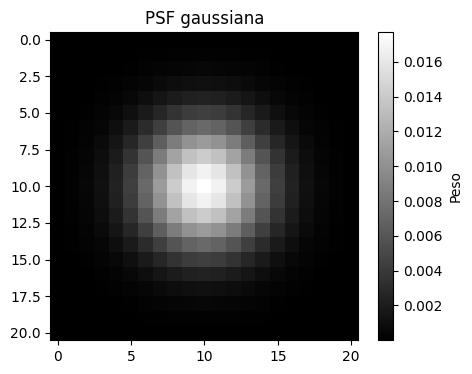

Shape: (21, 21)
Suma: 1.0


In [9]:
psf_gauss = gaussian_psf(size=21, sigma=3.0)

plt.figure(figsize=(5,4))
plt.imshow(psf_gauss)
plt.title("PSF gaussiana")
plt.colorbar(label="Peso")
plt.show()

print("Shape:", psf_gauss.shape)
print("Suma:", psf_gauss.sum())


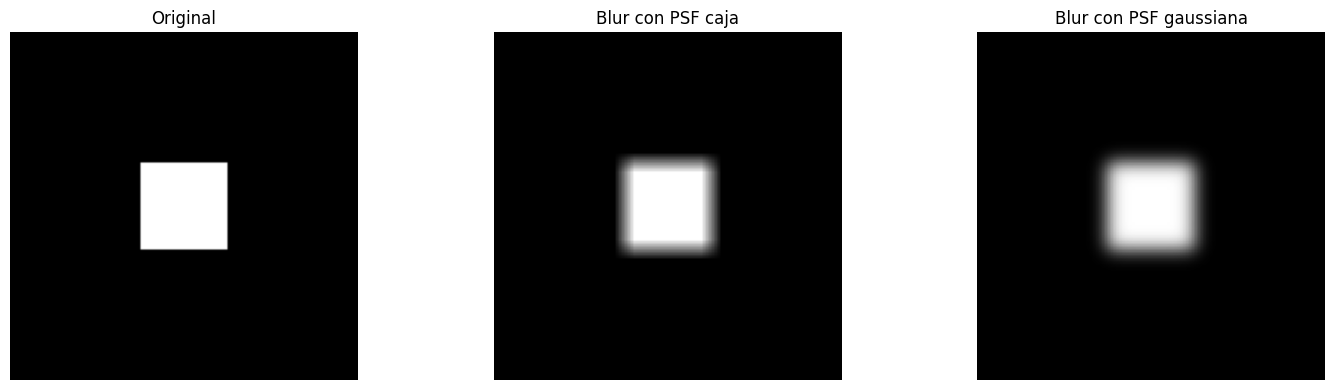

In [10]:
img_blur_gauss = convolve2d(img, psf_gauss, mode="same", boundary="fill", fillvalue=0)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(img, vmin=0, vmax=1)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(img_blur_box, vmin=0, vmax=1)
plt.title("Blur con PSF caja")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img_blur_gauss, vmin=0, vmax=1)
plt.title("Blur con PSF gaussiana")
plt.axis("off")

plt.tight_layout()
plt.show()


### Comparación conceptual

- La **PSF caja** reparte los pesos de forma uniforme.
- La **PSF gaussiana** concentra la mayor parte del peso cerca del centro.
- Una **PSF óptica real** puede ser aún más compleja: puede mostrar lóbulos, asimetrías o efectos de aberración.

Sin embargo, la gaussiana ya es suficiente para introducir una idea importante:

> la forma exacta de la PSF determina la forma exacta de la degradación.


## 10. Introducción al ruido

Hasta ahora solo hemos modelado el blur.

Pero una imagen real casi nunca llega limpia al archivo final.  
Siempre aparecen perturbaciones aleatorias.

Ese término lo representamos con:

$$
n(x,y)
$$

y puede deberse a:

- ruido térmico
- ruido de lectura
- cuantización
- baja iluminación
- fluctuaciones estadísticas de fotones
- electrónica del sistema

Agregaremos ruido gaussiano aditivo para visualizar el efecto.


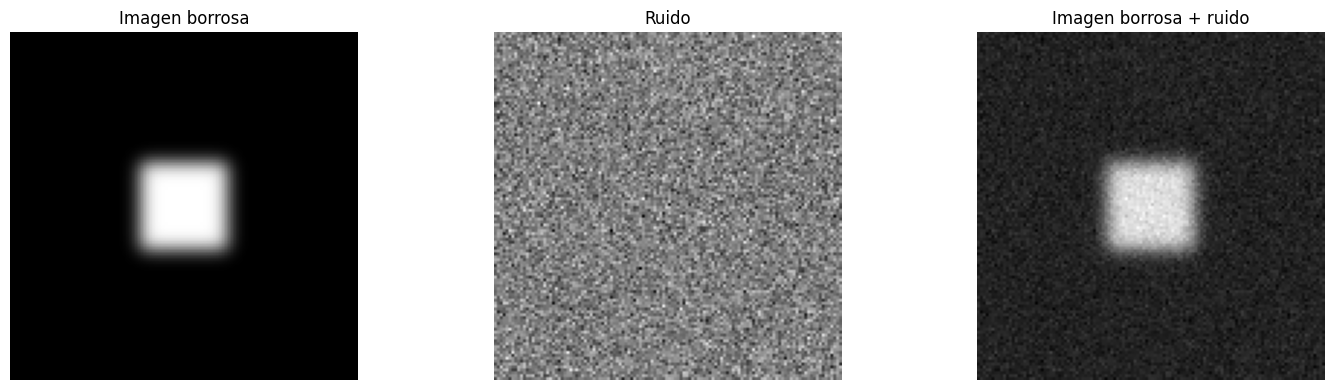

In [26]:
np.random.seed(42)

noise = np.random.normal(loc=0.0, scale=0.05, size=img.shape)
img_noisy = img_blur_gauss + noise

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(img_blur_gauss)
plt.title("Imagen borrosa")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noise)
plt.title("Ruido")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img_noisy)
plt.title("Imagen borrosa + ruido")
plt.axis("off")

plt.tight_layout()
plt.show()


### Dos degradaciones distintas

Ahora la imagen presenta dos deterioros superpuestos:

### 1. Blur
Es una degradación estructurada.  
Se debe a la respuesta del sistema.

### 2. Ruido
Es una degradación aleatoria.  
Se debe a la adquisición.

Esta distinción es fundamental porque:

- el blur suele borrar detalle
- el ruido suele introducir fluctuaciones no deseadas
- restaurar una imagen implica equilibrar ambos efectos


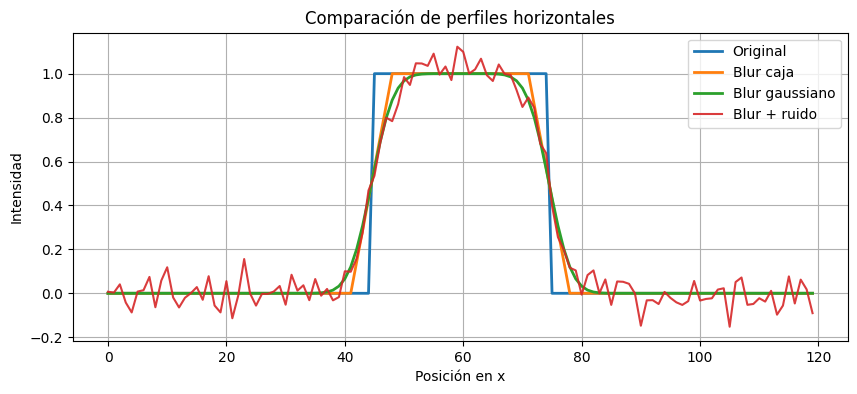

In [12]:
fila_noisy = img_noisy[img_noisy.shape[0] // 2, :]

plt.figure(figsize=(10,4))
plt.plot(fila_original, label="Original", linewidth=2)
plt.plot(fila_blur_box, label="Blur caja", linewidth=2)
plt.plot(img_blur_gauss[img_blur_gauss.shape[0] // 2, :], label="Blur gaussiano", linewidth=2)
plt.plot(fila_noisy, label="Blur + ruido", alpha=0.9)
plt.title("Comparación de perfiles horizontales")
plt.xlabel("Posición en x")
plt.ylabel("Intensidad")
plt.grid(True)
plt.legend()
plt.show()


En esta figura ya se ve el escenario realista:

- la forma global del objeto sigue allí
- los bordes están suavizados
- además hay oscilaciones aleatorias debidas al ruido

Este es el tipo de dato con el que trabajará casi cualquier sistema de reconstrucción real.


## 11. Visualización del pipeline completo

Construyamos una vista sintética del proceso entero.


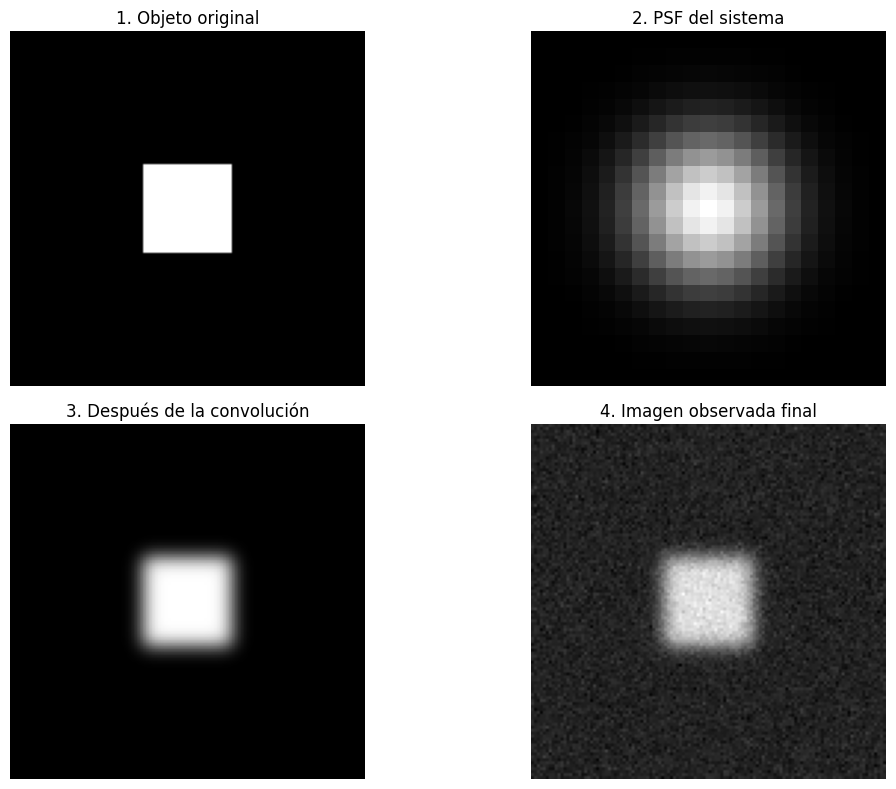

In [13]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img, vmin=0, vmax=1)
plt.title("1. Objeto original")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(psf_gauss)
plt.title("2. PSF del sistema")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(img_blur_gauss, vmin=0, vmax=1)
plt.title("3. Después de la convolución")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(img_noisy)
plt.title("4. Imagen observada final")
plt.axis("off")

plt.tight_layout()
plt.show()


La secuencia conceptual es:

**objeto → sistema → blur → ruido → imagen observada**

Esa es la cadena mínima de formación de imagen que debes tener en mente de ahora en adelante.


## 12. Relación con Fourier

Este capítulo se vuelve todavía más poderoso cuando se mira en el dominio de Fourier.

En el dominio espacial:

$$
g(x,y) = f(x,y) \otimes h(x,y)
$$

En el dominio frecuencial:

$$
G(f_x,f_y) = F(f_x,f_y)\,H(f_x,f_y)
$$

Esto significa que la convolución en espacio se transforma en multiplicación en frecuencia.

¿Por qué esto es tan importante?

Porque permite interpretar la acción del sistema como un filtrado frecuencial:

- muchas veces las altas frecuencias se atenúan
- por eso desaparecen detalles finos
- la imagen se vuelve más suave
- restaurar implica intentar recuperar esas componentes

Más adelante conectaremos esto con:

- OTF
- MTF
- deconvolución
- aprendizaje profundo para restauración
